In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import hashlib

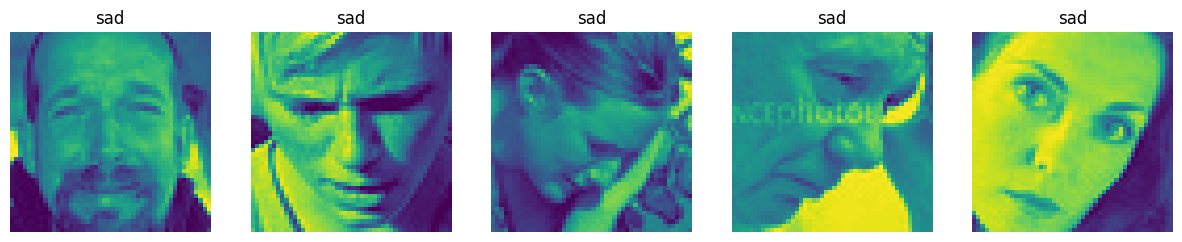

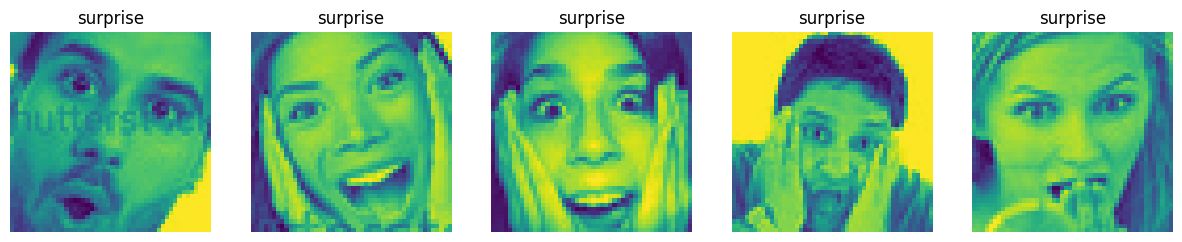

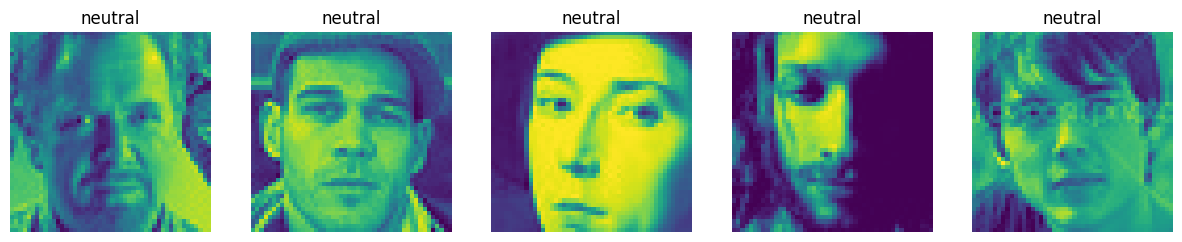

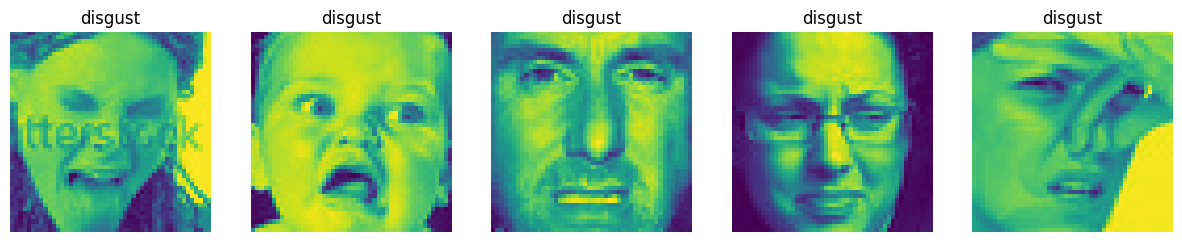

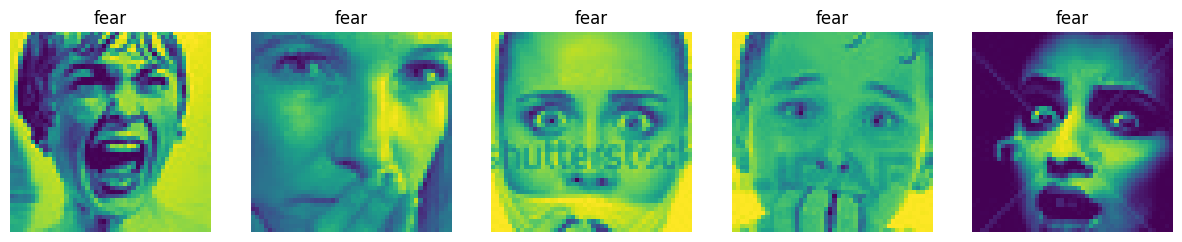

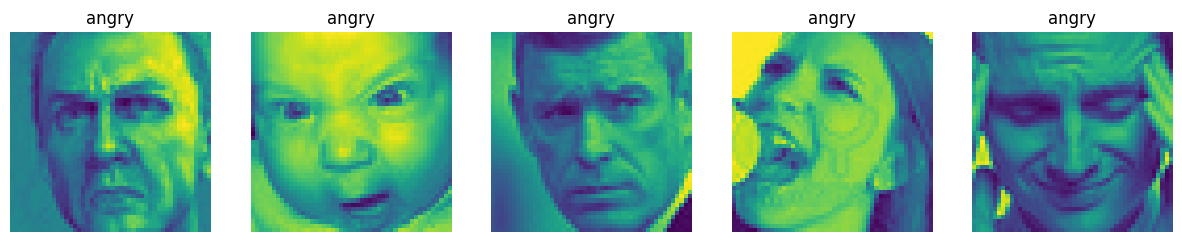

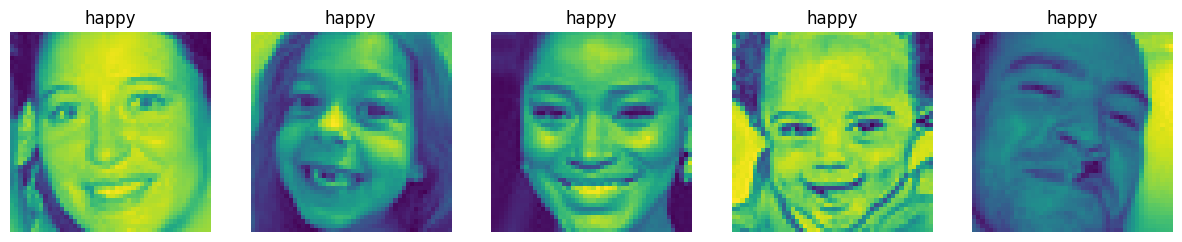

In [4]:
train_dir = "/content/train"

train_files = os.listdir(train_dir)

for files in train_files:
  files_dir = os.path.join(train_dir, files)

  images_files = os.listdir(files_dir)

  any5 = random.sample(images_files, 5)

  plt.figure(figsize=(15, 3))

  for i, image_file in enumerate(any5):
    img_path = os.path.join(files_dir, image_file)
    img = Image.open(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(files)
    plt.axis('off')

  plt.show()






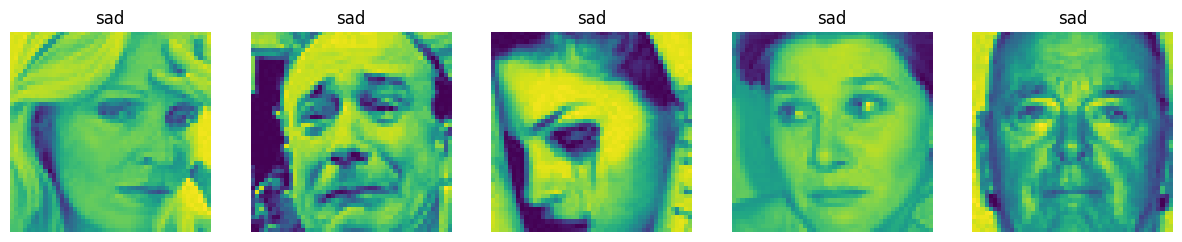

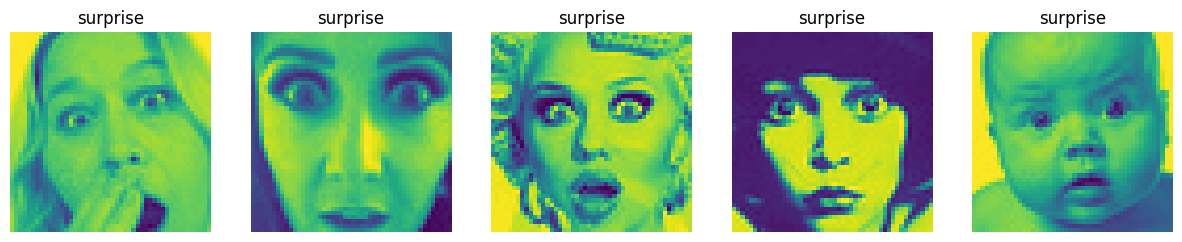

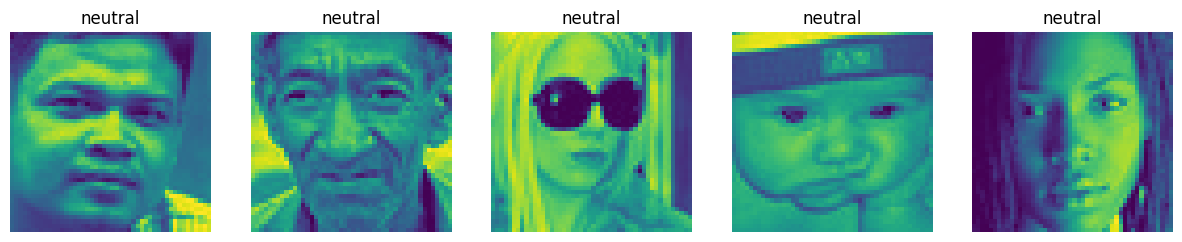

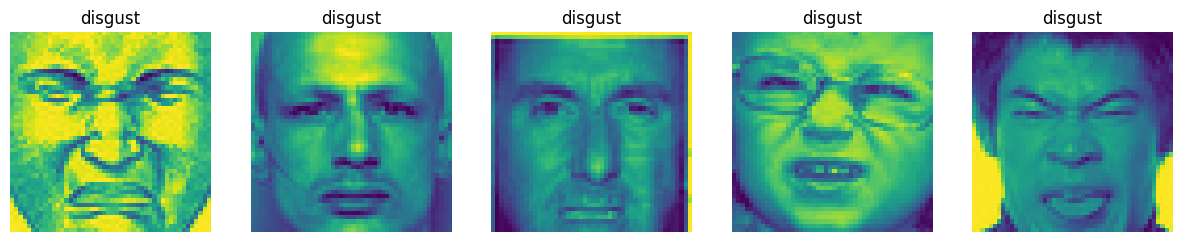

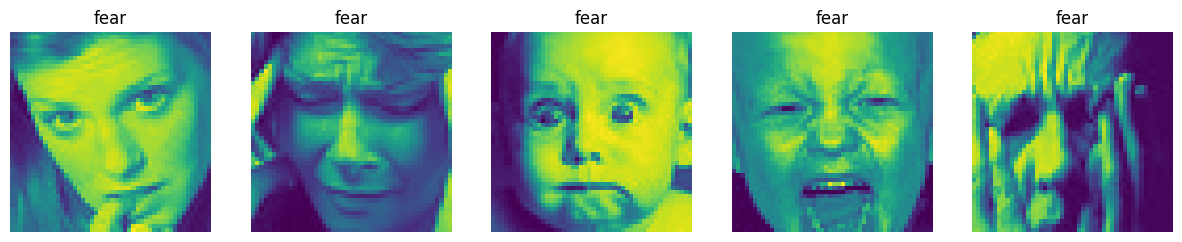

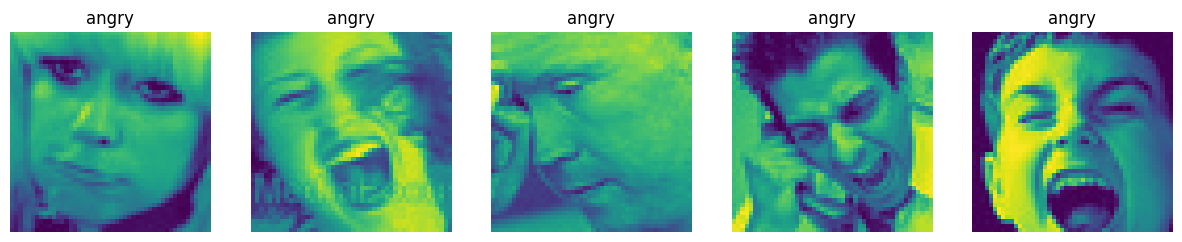

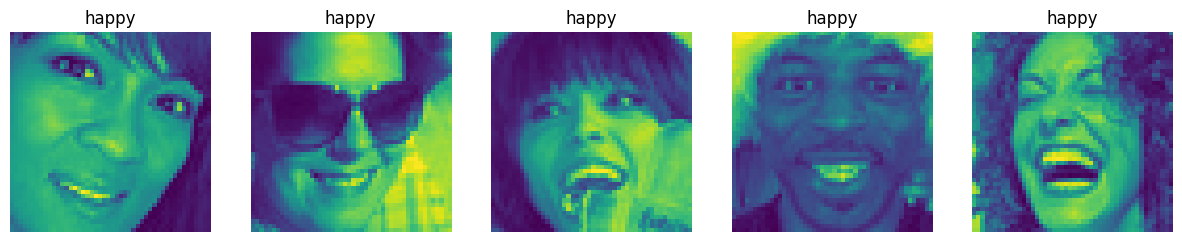

In [5]:
test_dir = "/content/test"

train_files = os.listdir(test_dir)

for files in train_files:
  files_dir = os.path.join(test_dir, files)

  images_files = os.listdir(files_dir)

  any5 = random.sample(images_files, 5)

  plt.figure(figsize=(15, 3))

  for i, image_file in enumerate(any5):
    img_path = os.path.join(files_dir, image_file)
    img = Image.open(img_path)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(files)
    plt.axis('off')

  plt.show()

# counting the number of image

In [6]:
train_dir = "/content/train"

train_files = os.listdir(train_dir)

for files in train_files:
  files_dir = os.path.join(train_dir, files)

  images_files = os.listdir(files_dir)

  print(f"Number of image in {files}:{len(images_files)}")


Number of image in sad:4830
Number of image in surprise:3171
Number of image in neutral:4965
Number of image in disgust:436
Number of image in fear:4097
Number of image in angry:3995
Number of image in happy:7215


# finding the number of duplicates

In [7]:
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dups = find_duplicates('/content/train')
print(f"Total duplicate files found: {len(dups)}")

Total duplicate files found: 1236


#duplicates in different classes

In [8]:
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file_data = f.read()
        hasher.update(file_data)
    return hasher.hexdigest()


def find_duplicates_with_classes(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                class_name = os.path.basename(os.path.dirname(file_path))

                if file_hash in hashes:
                    original_path = hashes[file_hash]['path']
                    original_class = hashes[file_hash]['class']

                    duplicates.append({
                        'duplicate_path': file_path,
                        'duplicate_class': class_name,
                        'original_path': original_path,
                        'original_class': original_class
                    })
                else:
                    hashes[file_hash] = {'path': file_path, 'class': class_name}

            except Exception as e:
                print(f"Error processing {file_path}: {e}")

    return duplicates


duplicates = find_duplicates_with_classes('/content/train')

print(f"Total duplicate files found: {len(duplicates)}\n")

duplicates_different_classes = 0
for dup in duplicates:
    if dup['duplicate_class'] != dup['original_class']:
        duplicates_different_classes+=1
        print(f"Duplicate Image : {dup['duplicate_path']} (Class: {dup['duplicate_class']})")
        print(f"Original Image  : {dup['original_path']} (Class: {dup['original_class']})")
print()
print("\n\n")
print("Total Number of duplicates with different classes :", duplicates_different_classes)

Total duplicate files found: 1236

Duplicate Image : /content/train/surprise/Training_48403842.jpg (Class: surprise)
Original Image  : /content/train/sad/Training_48621797.jpg (Class: sad)
Duplicate Image : /content/train/neutral/Training_20860064.jpg (Class: neutral)
Original Image  : /content/train/sad/Training_78533904.jpg (Class: sad)
Duplicate Image : /content/train/neutral/Training_89335926.jpg (Class: neutral)
Original Image  : /content/train/sad/Training_48621797.jpg (Class: sad)
Duplicate Image : /content/train/disgust/Training_27574839.jpg (Class: disgust)
Original Image  : /content/train/surprise/Training_5384838.jpg (Class: surprise)
Duplicate Image : /content/train/fear/Training_12587825.jpg (Class: fear)
Original Image  : /content/train/surprise/Training_63470176.jpg (Class: surprise)
Duplicate Image : /content/train/fear/Training_48719914.jpg (Class: fear)
Original Image  : /content/train/sad/Training_54602400.jpg (Class: sad)
Duplicate Image : /content/train/fear/Traini

In [9]:
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dups = find_duplicates('/content/train')
print(f"Total duplicate files found: {len(dups)}")

Total duplicate files found: 1236


# removing duplicate images

In [10]:
for dup in dups:
    duplicate_file = dup[0]

    if os.path.exists(duplicate_file):
        try:
            os.remove(duplicate_file)
            print(f"Deleted: {duplicate_file}")

        except Exception as e:
            print(f"Error deleting {duplicate_file}: {e}")

    else:
        print(f"File already deleted or not found: {duplicate_file}\n")

print("All duplicate images deletion check completed!")

Deleted: /content/train/sad/Training_22972393.jpg
Deleted: /content/train/sad/Training_95739380.jpg
Deleted: /content/train/sad/Training_19591457.jpg
Deleted: /content/train/sad/Training_6716869.jpg
Deleted: /content/train/sad/Training_37412108.jpg
Deleted: /content/train/sad/Training_33044906.jpg
Deleted: /content/train/sad/Training_55352494.jpg
Deleted: /content/train/sad/Training_45117163.jpg
Deleted: /content/train/sad/Training_47011585.jpg
Deleted: /content/train/sad/Training_95949434.jpg
Deleted: /content/train/sad/Training_1928268.jpg
Deleted: /content/train/sad/Training_7587826.jpg
Deleted: /content/train/sad/Training_68142058.jpg
Deleted: /content/train/sad/Training_26707152.jpg
Deleted: /content/train/sad/Training_30529781.jpg
Deleted: /content/train/sad/Training_1916256.jpg
Deleted: /content/train/sad/Training_54609626.jpg
Deleted: /content/train/sad/Training_50102721.jpg
Deleted: /content/train/sad/Training_50600363.jpg
Deleted: /content/train/sad/Training_70378996.jpg
Dele

In [11]:
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dups = find_duplicates('/content/train')
print(f"Total duplicate files found: {len(dups)}")

Total duplicate files found: 0


# For test Data

In [13]:
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dupst = find_duplicates('/content/test')
print(f"Total duplicate files found: {len(dupst)}")

Total duplicate files found: 86


In [14]:
for dup in dupst:
    duplicate_file = dup[0]

    if os.path.exists(duplicate_file):
        try:
            os.remove(duplicate_file)
            print(f"Deleted: {duplicate_file}")

        except Exception as e:
            print(f"Error deleting {duplicate_file}: {e}")

    else:
        print(f"File already deleted or not found: {duplicate_file}\n")

print("All duplicate images deletion check completed!")

Deleted: /content/test/sad/PrivateTest_70680879.jpg
Deleted: /content/test/sad/PrivateTest_37843789.jpg
Deleted: /content/test/sad/PrivateTest_11904014.jpg
Deleted: /content/test/sad/PrivateTest_24324231.jpg
Deleted: /content/test/sad/PrivateTest_22191391.jpg
Deleted: /content/test/sad/PublicTest_64953069.jpg
Deleted: /content/test/surprise/PrivateTest_13291266.jpg
Deleted: /content/test/surprise/PublicTest_81489797.jpg
Deleted: /content/test/surprise/PublicTest_61597434.jpg
Deleted: /content/test/surprise/PrivateTest_20993679.jpg
Deleted: /content/test/surprise/PublicTest_17911043.jpg
Deleted: /content/test/surprise/PrivateTest_90663142.jpg
Deleted: /content/test/surprise/PublicTest_90324585.jpg
Deleted: /content/test/surprise/PublicTest_4915092.jpg
Deleted: /content/test/surprise/PublicTest_3560560.jpg
Deleted: /content/test/surprise/PrivateTest_59195628.jpg
Deleted: /content/test/surprise/PrivateTest_76249877.jpg
Deleted: /content/test/surprise/PrivateTest_36377429.jpg
Deleted: /con

In [15]:
def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dupst = find_duplicates('/content/test')
print(f"Total duplicate files found: {len(dupst)}")

Total duplicate files found: 0


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, Rescaling,
                                     RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [17]:
train_dir = '/content/train'
val_dir = '/content/test'
model_save_path = 'cnn_custom_first_model.keras'

class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
IMG_SIZE = (48, 48)
BATCH_SIZE = 128
EPOCHS = 100

# First model

In [18]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='categorical',
    color_mode='grayscale',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

data_augmentation = Sequential([
    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])


Found 27473 files belonging to 7 classes.
Found 7092 files belonging to 7 classes.


In [19]:
model = Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    # ✅ Data Augmentation Layer
    data_augmentation,

    # ✅ Block 1
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ✅ Block 2
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ✅ Block 3
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # ✅ Fully Connected Layer
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # ✅ Output Layer
    Dense(7, activation='softmax', dtype='float32')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,04

 Total params: 5,872,583 (22.40 MB)

 Trainable params: 5,869,767 (22.39 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        patience=10,
        monitor='val_loss',
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=model_save_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.2308 - loss: 2.3784
Epoch 1: val_accuracy improved from None to 0.20558, saving model to cnn_custom_first_model.keras

Epoch 1: finished saving model to cnn_custom_first_model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 39s 127ms/step - accuracy: 0.2672 - loss: 2.0992 - val_accuracy: 0.2056 - val_loss: 1.9963
Epoch 2/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.3534 - loss: 1.7288
Epoch 2: val_accuracy improved from 0.20558 to 0.33672, saving model to cnn_custom_first_model.keras

Epoch 2: finished saving model to cnn_custom_first_model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - accuracy: 0.3769 - loss: 1.6577 - val_accuracy: 0.3367 - val_loss: 1.6669
Epoch 3/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4060 - loss: 1.5821
Epoch 3: val_accuracy improved from 0.33672 to 0.43401, saving model to cnn_custom_first_model.keras

Epoch 3: finished saving model to cnn_custom_first_model.keras
2

In [21]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())

# ✅ Classification Report
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━

# second Model

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, Rescaling,
                                     RandomFlip, RandomRotation, RandomZoom)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

# Re-defining and training the model with tweaked parameters

# Tweak 1: Increase dropout rates
# Original: 0.25, 0.25, 0.25, 0.5
# New:      0.35, 0.35, 0.35, 0.6

# Tweak 2: Adjust Adam optimizer learning rate to 0.0005 (from default 0.001)

model_tuned = Sequential([
    tf.keras.Input(shape=IMG_SIZE + (1,)),

    data_augmentation, # Use existing data_augmentation layer

    # Block 1
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35), # Increased dropout

    # Block 2
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35), # Increased dropout

    # Block 3
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35), # Increased dropout

    # Fully Connected Layer
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.6), # Increased dropout

    # Output Layer
    Dense(7, activation='softmax', dtype='float32')
])

model_tuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Tweaked learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Use existing callbacks (EarlyStopping, ModelCheckpoint)
# Ensure model_save_path is correctly set for the new model if user wants to save
# For this example, let's change the save path to distinguish it.
model_tuned_save_path = 'cnn_custom_tuned_model.keras'
callbacks_tuned = [
    EarlyStopping(
        patience=10,
        monitor='val_loss',
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=model_tuned_save_path, # New save path
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]


print("Training with tweaked parameters...")
history_tuned = model_tuned.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS, # Use existing EPOCHS
    callbacks=callbacks_tuned
)

# Evaluate the tuned model
y_true_tuned = []
y_pred_tuned = []

for images, labels in val_ds:
    preds_tuned = model_tuned.predict(images)
    y_true_tuned.extend(tf.argmax(labels, axis=1).numpy())
    y_pred_tuned.extend(tf.argmax(preds_tuned, axis=1).numpy())

print("\n📋 Classification Report for Tuned Model:\n")
print(classification_report(y_true_tuned, y_pred_tuned, target_names=class_names, digits=4))

Training with tweaked parameters...
Epoch 1/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1982 - loss: 2.7675
Epoch 1: val_accuracy improved from None to 0.17696, saving model to cnn_custom_tuned_model.keras

Epoch 1: finished saving model to cnn_custom_tuned_model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.2264 - loss: 2.4370 - val_accuracy: 0.1770 - val_loss: 1.9593
Epoch 2/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2889 - loss: 1.9998
Epoch 2: val_accuracy improved from 0.17696 to 0.28356, saving model to cnn_custom_tuned_model.keras

Epoch 2: finished saving model to cnn_custom_tuned_model.keras
215/215 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.3082 - loss: 1.9187 - val_accuracy: 0.2836 - val_loss: 1.8479
Epoch 3/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3480 - loss: 1.7351
Epoch 3: val_accuracy improved from 0.28356 to 0.42061, saving model to cnn_custom_tuned_model.keras

Epoch 3: finished saving mod

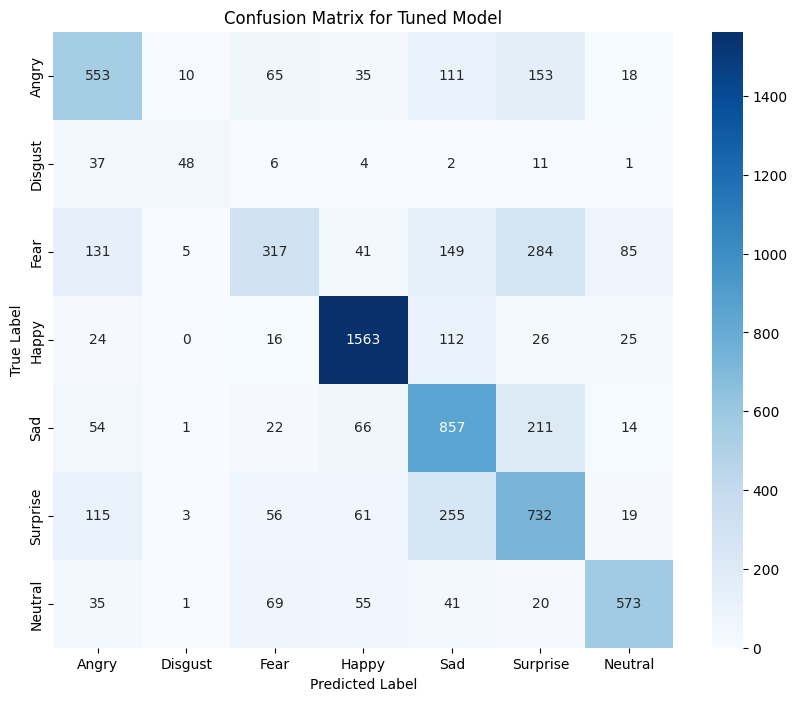

In [23]:
# ✅ Confusion Matrix
cm_tuned = confusion_matrix(y_true_tuned, y_pred_tuned)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()